In [1]:
import pandas as pd

<h2> 1. Импорт и анализ таблиц</h2>

In [2]:
all_sheets = pd.read_excel('Новый диплом датасет update.xlsx', sheet_name=None)

In [3]:
# Посмотреть названия всех листов
print("Названия листов:", all_sheets.keys())

Названия листов: dict_keys(['Данные', 'Clients', 'Region_dict'])


In [4]:
df_payments = all_sheets['Данные'].copy()        # платежи
df_clients = all_sheets['Clients'].copy()        # клиенты
df_regions = all_sheets['Region_dict'].copy()   # регионы

**--------------Таблица 'Данные' (платежи)----------------**

In [5]:
print(df_payments.head())

   id_order  id_client  amt_payment               dtime_pay
0    100238   194569.0       5373.0 2022-07-17 21:48:15.896
1    100242   191056.0       4151.0 2022-07-07 03:09:39.699
2    100249   200049.0       5688.0 2022-07-29 13:25:59.976
3    100258   206161.0       4330.0 2022-08-15 22:55:02.538
4    100267   190945.0       5488.0 2022-07-05 19:46:47.174


In [6]:
print(len(df_payments))

37989


In [7]:
print(df_payments.isnull().sum())

id_order          0
id_client       588
amt_payment    2144
dtime_pay      2429
dtype: int64


In [8]:
df_payments_clean = df_payments.dropna()

In [9]:
print(len(df_payments_clean))

35560


**-------------------Таблица 'Clients'-----------------------------**

In [10]:
print(df_clients.head())

   id_client                dtime_ad  nflag_test  id_trading_point
0     180844 2022-06-08 18:38:41.414           0               212
1     193942                     NaT           0                13
2     226069 2022-07-11 16:28:38.511           1                54
3     183981 2022-06-16 12:23:59.289           1               991
4     322530 2022-07-08 08:56:08.714           0              1015


In [11]:
print(df_clients.isnull().sum())

id_client             0
dtime_ad            249
nflag_test            0
id_trading_point      0
dtype: int64


In [12]:
print(len(df_clients))

55605


In [13]:
df_clients_clean = df_clients.dropna()

In [14]:
print(len(df_clients_clean))

55356


**------------------- Таблица 'Region_dict' --------------------**

In [15]:
print(df_regions.head())

   id_trading_point            city
0                 1    Петрозаводск
1                 2         Дмитров
2                 4           Чехов
3                 7  Ростов Великий
4                11        Владимир


In [16]:
print(df_regions.isnull().sum())

id_trading_point    0
city                0
dtype: int64


**Очищенные таблицы:  
df_payments_clean  
df_clients_clean  
df_regions**

In [17]:
###########################################################################################################

Исследуйте количество торговых точек в каждом городе — постройте группировку по количеству в каждом городе  
и визуализируйте с помощью столбчатой диаграммы.

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df_regions.head()

,id_trading_point,city
0,1,Петрозаводск
1,2,Дмитров
2,4,Чехов
3,7,Ростов Великий
4,11,Владимир


In [20]:
#Кол-во торговых точек в каждом городе
city_counts = df_regions.groupby('city')['id_trading_point'].count().reset_index()
city_counts.columns = ['Город','Количество_точек']

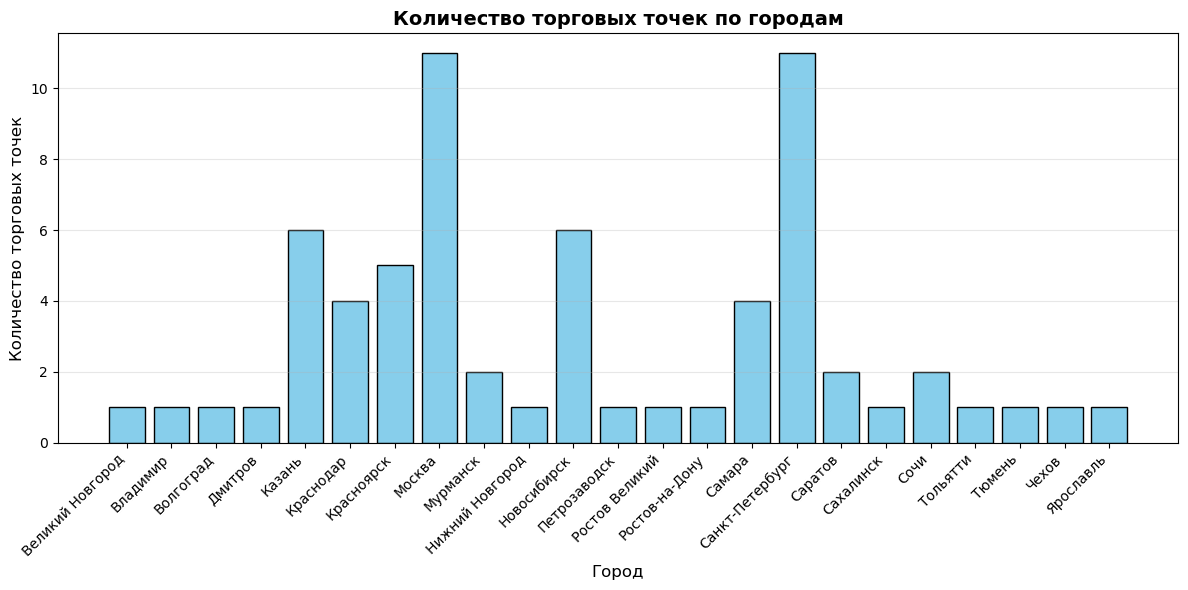

In [21]:
#  Базовая столбчатая диаграмма
plt.figure(figsize=(12, 6))
plt.bar(city_counts['Город'], city_counts['Количество_точек'], color='skyblue', edgecolor='black')
plt.xlabel('Город', fontsize=12)
plt.ylabel('Количество торговых точек', fontsize=12)
plt.title('Количество торговых точек по городам', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<h2> 2. Объединение таблиц </h2>

Постройте агрегацию таблицы с платежами, где вычислите сумму платежей на каждого клиента.

In [22]:
#df_payments_clean

In [23]:
client_total = df_payments_clean.groupby('id_client')['amt_payment'].sum().reset_index()

client_total.columns = ['id_client', 'total_payment']


In [24]:
client_total.head()

,id_client,total_payment
0,178561.0,3052.0
1,178562.0,2439.0
2,178563.0,768.0
3,178565.0,958.0
4,178566.0,5474.0


In [25]:
#client_total and df_clients_clean

In [26]:
df_merged = pd.merge(client_total, df_clients_clean, on = 'id_client', how = 'right')

In [27]:
df_merged.head()

,id_client,total_payment,dtime_ad,nflag_test,id_trading_point
0,180844.0,5349.0,2022-06-08 18:38:41.414,0,212
1,226069.0,NaN,2022-07-11 16:28:38.511,1,54
2,183981.0,6322.0,2022-06-16 12:23:59.289,1,991
3,322530.0,NaN,2022-07-08 08:56:08.714,0,1015
4,254313.0,NaN,2022-06-19 22:18:01.770,1,453


In [28]:
print(df_merged['id_client'].duplicated().sum())

0


In [29]:
########################################################################

Заполните нулями суммы покупок тех клиентов, которые их не совершали.

In [30]:
client_without_payments = df_merged[df_merged['total_payment'].isnull()]
print(len(client_without_payments))

26973


In [31]:
df_merged['total_payment'] = df_merged['total_payment'].fillna(0)

In [32]:
client_without_payments = df_merged[df_merged['total_payment'].isnull()]
print(len(client_without_payments))

0


In [33]:
########################################################################

С помощью словаря регионов подтяните к каждой торговой точке город, в котором она находится.

In [34]:
#df_merged и df_regions

In [35]:
df_with_city = pd.merge( df_merged, df_regions,
                         on = 'id_trading_point', how = 'left')
print(df_with_city.head())

   id_client  total_payment                dtime_ad  nflag_test  \
0   180844.0         5349.0 2022-06-08 18:38:41.414           0   
1   226069.0            0.0 2022-07-11 16:28:38.511           1   
2   183981.0         6322.0 2022-06-16 12:23:59.289           1   
3   322530.0            0.0 2022-07-08 08:56:08.714           0   
4   254313.0            0.0 2022-06-19 22:18:01.770           1   

   id_trading_point             city  
0               212       Красноярск  
1                54         Мурманск  
2               991           Казань  
3              1015        Краснодар  
4               453  Санкт-Петербург  


In [36]:
clients_without_city = df_with_city[df_with_city['city'].isnull()]
print(len(clients_without_city))

0


In [37]:
#########################################################################################################

Создайте поле флаг платежа, который принимает значения 0 или 1 в зависимости от того, заплатил клиент или нет.

In [38]:
df_with_city['payment_flag'] = df_with_city['total_payment'].apply(lambda x: 1 if x > 0 else 0)

In [39]:
df_with_city.head()

,id_client,total_payment,dtime_ad,nflag_test,id_trading_point,city,payment_flag
0,180844.0,5349.0,2022-06-08 18:38:41.414,0,212,Красноярск,1
1,226069.0,0.0,2022-07-11 16:28:38.511,1,54,Мурманск,0
2,183981.0,6322.0,2022-06-16 12:23:59.289,1,991,Казань,1
3,322530.0,0.0,2022-07-08 08:56:08.714,0,1015,Краснодар,0
4,254313.0,0.0,2022-06-19 22:18:01.770,1,453,Санкт-Петербург,0


<h2> 3. Автоматизация статистических вычислений </h2>

Создайте функцию test_calc, которая будет вычислять значение t-критерия (критерия Стьюдента)  
и p_value для сравнения средних и с помощью функции print выводить сообщение о том,  
существует ли разница между средними (на основании p_value).  
Аргументы функции: r1 (первая выборка), r2 (вторая выборка), alpha  
(уровень значимости, имеет значение по умолчанию 5%).

In [40]:
import numpy as np
from scipy import stats

In [41]:
def test_calc(r1, r2, alpha = 0.05):

    if len(r1)==0 or len(r2)==0:
        print("Одна из выборок пуста")
        return None, None

    t_stat, p_value = stats.ttest_ind(r1, r2, equal_var = False)

    print(t_stat)
    print(p_value)

    if p_value < alpha:
        print('Разница между средними статистически значима')
    else:
        print('Разницы между средними статистическими значениями нет')

    return t_stat, p_value

Создайте функцию mann_whitney_func, которая будет рассчитывать значение критерия Манна Уитни и p_value  
для сравнения распределений и с помощью функции print выводить сообщение о том, существует ли разница  
между средними (на основании p_value).  
Аргументы функции: r1 (первая выборка), r2 (вторая выборка), alpha (уровень значимости,  
имеет значение по умолчанию 5%).

In [42]:
def mann_whitney_func(r1, r2, alpha = 0.05):

    if len(r1) == 0 or len(r2) == 0:
        print("Одна из выборок пуста")
        return None, None

    u_stat, p_value = stats.mannwhitneyu(r1, r2, alternative = 'two-sided')

    print(u_stat)
    print(p_value)

    if p_value < alpha:
        print('Разница между распределениями статистически значима')
    else:
        print('Разницы между средними статистическими значениями нет')

    return u_stat, p_value

<h2>4. Чистка неверно заполненных точек</h2>

Создайте пустой список. Запустите цикл по всем торговым точкам и добавьте к этому списку все торговые точки,  
в которых в тестовой или в контрольной группе не было заплачено ни одного рубля ни одним клиентом.

In [43]:
# Создаем пустой список для торговых точек без платежей
points_without_payments = []

# Получаем уникальные торговые точки
unique_points = df_with_city['id_trading_point'].unique()

# Запускаем цикл по всем торговым точкам
for point in unique_points:
    # Фильтруем данные для текущей торговой точки
    point_data = df_with_city[df_with_city['id_trading_point'] == point]
    
    # Проверяем тестовую группу (nflag_test == 1)
    test_group = point_data[point_data['nflag_test'] == 1]
    test_payments = test_group[test_group['total_payment'] > 0]
    
    # Проверяем контрольную группу (nflag_test == 0)
    control_group = point_data[point_data['nflag_test'] == 0]
    control_payments = control_group[control_group['total_payment'] > 0]
    
    # Если в тестовой группе нет платежей или в контрольной группе нет платежей
    if len(test_payments) == 0 or len(control_payments) == 0:
        points_without_payments.append(point)

# Выводим результаты
print(f"Всего торговых точек: {len(unique_points)}")
print(f"Торговых точек без платежей в обеих группах: {len(points_without_payments)}")
print(f"Список точек без платежей: {points_without_payments}")

Всего торговых точек: 66
Торговых точек без платежей в обеих группах: 15
Список точек без платежей: [np.int64(1015), np.int64(866), np.int64(1099), np.int64(739), np.int64(46), np.int64(228), np.int64(26), np.int64(603), np.int64(810), np.int64(800), np.int64(7), np.int64(23), np.int64(4), np.int64(1), np.int64(13)]


In [44]:
#################################################################################################################

Создайте еще один пустой список. Запустите цикл по всем торговым точкам и добавьте к этому списку все торговые точки,  
в которых пустует или контрольная, или тестовая группа.


In [45]:
# Создаем пустой список для торговых точек с пустующей группой
points_with_empty_group = []

# Получаем уникальные торговые точки
unique_points = df_with_city['id_trading_point'].unique()

# Запускаем цикл по всем торговым точкам
for point in unique_points:
    # Фильтруем данные для текущей торговой точки
    point_data = df_with_city[df_with_city['id_trading_point'] == point]
    
    # Проверяем тестовую группу (nflag_test == 1)
    test_group = point_data[point_data['nflag_test'] == 1]
    test_count = len(test_group)
    test_payments = test_group[test_group['total_payment'] > 0]
    
    # Проверяем контрольную группу (nflag_test == 0)
    control_group = point_data[point_data['nflag_test'] == 0]
    control_count = len(control_group)
    control_payments = control_group[control_group['total_payment'] > 0]
    
    # Если тестовая группа пуста или контрольная группа пуста
    if (test_count == 0 or control_count == 0) or (len(test_payments) == 0 or len(control_payments) == 0):
        points_with_empty_group.append(point)

# Выводим результаты
print(f"Всего торговых точек: {len(unique_points)}")
print(f"Торговых точек с пустующей группой или без платежей: {len(points_with_empty_group)}")
print(f"Список точек с пустующей группой или без платежей: {points_with_empty_group}")

Всего торговых точек: 66
Торговых точек с пустующей группой или без платежей: 15
Список точек с пустующей группой или без платежей: [np.int64(1015), np.int64(866), np.int64(1099), np.int64(739), np.int64(46), np.int64(228), np.int64(26), np.int64(603), np.int64(810), np.int64(800), np.int64(7), np.int64(23), np.int64(4), np.int64(1), np.int64(13)]


<h2> 5. Расчет общих результатов A/B-теста </h2>

Отбросьте все торговые точки, которые были вами обнаружены в пункте 4. Пояснение: если сумма платежей  
или количество наблюдений в одной из групп будет равно 0, то мы не сможем сравнить платежи в тестовой  
и контрольной группах, или такое сравнение будет неверным.

In [46]:
# проблемные точки 
problematic_points = set()

for point in df_with_city['id_trading_point'].unique():
    point_data = df_with_city[df_with_city['id_trading_point'] == point]
    
    # Проверка на пустующую группу
    test_count = len(point_data[point_data['nflag_test'] == 1])
    control_count = len(point_data[point_data['nflag_test'] == 0])
    
    # Проверка на отсутствие платежей
    test_payments = point_data[(point_data['nflag_test'] == 1) & (point_data['total_payment'] > 0)]
    control_payments = point_data[(point_data['nflag_test'] == 0) & (point_data['total_payment'] > 0)]
    
    # выискиваем проблемные точки
    if (test_count == 0 or control_count == 0) or (len(test_payments) == 0 or len(control_payments) == 0):
        problematic_points.add(point)

# создаем новый датасет без проблемных точек
df_filtered = df_with_city[~df_with_city['id_trading_point'].isin(problematic_points)].copy()

print(f"Отброшено точек: {len(problematic_points)}")
print(f"Осталось точек: {len(df_filtered['id_trading_point'].unique())}")
print('Итоговый датафрейм df_filtered')

Отброшено точек: 15
Осталось точек: 51
Итоговый датафрейм df_filtered


In [47]:
####################################################################################################

Изобразите гистограмму платежей, на которой различными цветами изображены группы «тест» и «контроль».

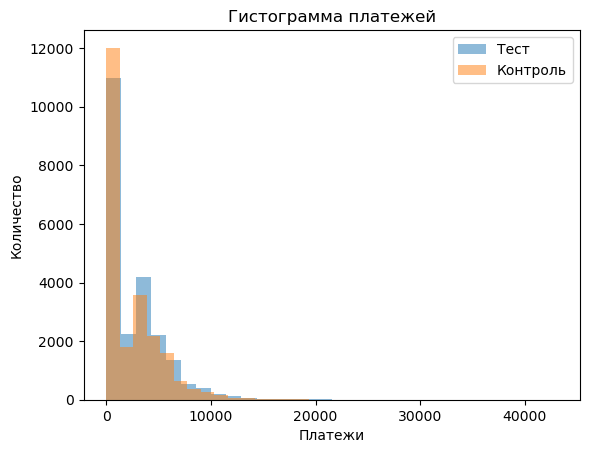

In [48]:
test = df_filtered[df_filtered['nflag_test'] == 1]['total_payment']
control = df_filtered[df_filtered['nflag_test'] == 0]['total_payment']

plt.hist(test, bins=30, alpha=0.5, label='Тест')
plt.hist(control, bins=30, alpha=0.5, label='Контроль')
plt.xlabel('Платежи')
plt.ylabel('Количество')
plt.title('Гистограмма платежей')
plt.legend()
plt.show()

Примените функцию test_calc и сделайте вывод (сравниваем средние платежи).

In [49]:
test_payments = df_filtered[df_filtered['nflag_test'] == 1]['total_payment']
control_payments = df_filtered[df_filtered['nflag_test'] == 0]['total_payment']

t_stat, p_value = test_calc(test_payments, control_payments, alpha=0.05)


9.452654239576423
3.456057606199937e-21
Разница между средними статистически значима


**Вывод:** Средние значения в группах значительно отличаются, а критерий p_value практически равен 0,  
отсюда можно сделать вывод, что тестовая группа работает лучше!

In [50]:
##############################################################################################

Примените функцию test_calc и сделайте вывод (сравниваем конверсию в платеж, то есть r1 и r2 —  
это ряды нулей и единиц, в зависимости от того, оплатил ли что-то клиент или нет).

In [51]:
df_filtered.loc[:, 'conversion'] = (df_filtered['total_payment'] > 0).astype(int)

r1 = df_filtered[df_filtered['nflag_test'] == 1]['conversion']  # тестовая группа
r2 = df_filtered[df_filtered['nflag_test'] == 0]['conversion']  # контрольная группа

t_stat, p_value = test_calc(r1, r2, alpha=0.05)

9.282362400356972
1.7284765137365496e-20
Разница между средними статистически значима


**Вывод:** Конверсия в тестовой группе  намного выше, чем в контрольной. 

In [52]:
###############################################################################################

Примените функцию mann_whitney_func и сделайте вывод.

In [53]:
r1 = df_filtered[df_filtered['nflag_test'] == 1]['total_payment']  # тестовая группа
r2 = df_filtered[df_filtered['nflag_test'] == 0]['total_payment']  # контрольная группа

u_stat, p_value = mann_whitney_func(r1, r2, alpha=0.05)

median_test = np.median(r1)
median_control = np.median(r2)

if median_test > median_control:
    print("Тестовая группа платит больше")
else:
    print("Тестовая группа платит меньше")


270040116.0
3.008345273971901e-24
Разница между распределениями статистически значима
Тестовая группа платит больше


**Вывод:** На основе критерия Манна-Уитни, распределение платежей в тестовой группе  
статистически значимо отличается от распределения в контрольной группе- тестовая  
группа платит больше, чем контрольная.

<h2> 6. Сегментация результатов A/B-теста </h2>

Повторите аналитику из пункта 5 в отношении **Москвы**. Сделайте выводы.

In [54]:
print(df_with_city['city'].unique())

['Красноярск' 'Мурманск' 'Казань' 'Краснодар' 'Санкт-Петербург' 'Москва'
 'Новосибирск' 'Ярославль' 'Саратов' 'Тольятти' 'Тюмень' 'Волгоград'
 'Сочи' 'Владимир' 'Самара' 'Ростов-на-Дону' 'Ростов Великий' 'Сахалинск'
 'Великий Новгород' 'Чехов' 'Петрозаводск' 'Нижний Новгород' 'Дмитров']


In [55]:
#фильтруем нужный город
moscow = df_filtered[df_filtered['city'] == 'Москва'].copy()

if len(moscow) > 0:
    # Создаем конверсию
    moscow['conversion'] = (moscow['total_payment'] > 0).astype(int)

    # Данные для теста
    test_pay = moscow[moscow['nflag_test'] == 1]['total_payment']
    control_pay = moscow[moscow['nflag_test'] == 0]['total_payment']
    test_conv = moscow[moscow['nflag_test'] == 1]['conversion']
    control_conv = moscow[moscow['nflag_test'] == 0]['conversion']

    print("\n СРАВНЕНИЕ СРЕДНИХ ПЛАТЕЖЕЙ:")
    test_calc(test_pay, control_pay)

    print("\n СРАВНЕНИЕ КОНВЕРСИИ:")
    test_calc(test_conv, control_conv)

    print("\n СРАВНЕНИЕ РАСПРЕДЕЛЕНИЙ:")
    mann_whitney_func(test_pay, control_pay)

    # Итоговый вывод
    print("\n")
    print("**ВЫВОД ПО МОСКВЕ:**")
    print(f"Средний платеж (тест): {test_pay.mean():.2f} рублей")
    print(f"Средний платеж (контроль): {control_pay.mean():.2f} рублей")
    print(f"Конверсия (тест): {test_conv.mean()*100:.2f}%")
    print(f"Конверсия (контроль): {control_conv.mean()*100:.2f}%")

else:
    print("Нет данных по Москве")


 СРАВНЕНИЕ СРЕДНИХ ПЛАТЕЖЕЙ:
7.672097996911047
1.8199520669736726e-14
Разница между средними статистически значима

 СРАВНЕНИЕ КОНВЕРСИИ:
6.19047063650437
6.18851179009111e-10
Разница между средними статистически значима

 СРАВНЕНИЕ РАСПРЕДЕЛЕНИЙ:
20595574.5
7.010591402203484e-16
Разница между распределениями статистически значима


**ВЫВОД ПО МОСКВЕ:**
Средний платеж (тест): 2367.96 рублей
Средний платеж (контроль): 1986.18 рублей
Конверсия (тест): 54.35%
Конверсия (контроль): 48.79%


Повторите аналитику из пункта 5 в отношении **Санкт-Петербурга**. Сделайте выводы.

In [56]:
#фильтруем нужный город
piter = df_filtered[df_filtered['city'] == 'Санкт-Петербург'].copy()

if len(piter) > 0:
    # Создаем конверсию
    piter['conversion'] = (piter['total_payment'] > 0).astype(int)

    # Данные для теста
    test_pay = piter[piter['nflag_test'] == 1]['total_payment']
    control_pay = piter[piter['nflag_test'] == 0]['total_payment']
    test_conv = piter[piter['nflag_test'] == 1]['conversion']
    control_conv = piter[piter['nflag_test'] == 0]['conversion']

    print("\n СРАВНЕНИЕ СРЕДНИХ ПЛАТЕЖЕЙ:")
    test_calc(test_pay, control_pay)

    print("\n СРАВНЕНИЕ КОНВЕРСИИ:")
    test_calc(test_conv, control_conv)

    print("\n СРАВНЕНИЕ РАСПРЕДЕЛЕНИЙ:")
    mann_whitney_func(test_pay, control_pay)

    # Итоговый вывод
    print("\n")
    print("**ВЫВОД ПО САНКТ-ПЕТЕРБУРГУ:**")
    print(f"Средний платеж (тест): {test_pay.mean():.2f} рублей")
    print(f"Средний платеж (контроль): {control_pay.mean():.2f} рублей")
    print(f"Конверсия (тест): {test_conv.mean()*100:.2f}%")
    print(f"Конверсия (контроль): {control_conv.mean()*100:.2f}%")

else:
    print("Нет данных по Санкт-Петербургу")


 СРАВНЕНИЕ СРЕДНИХ ПЛАТЕЖЕЙ:
8.760567570492698
2.303567502922061e-18
Разница между средними статистически значима

 СРАВНЕНИЕ КОНВЕРСИИ:
9.352479120817705
1.0657220952695895e-20
Разница между средними статистически значима

 СРАВНЕНИЕ РАСПРЕДЕЛЕНИЙ:
10899685.5
2.0392184217953754e-20
Разница между распределениями статистически значима


**ВЫВОД ПО САНКТ-ПЕТЕРБУРГУ:**
Средний платеж (тест): 2427.46 рублей
Средний платеж (контроль): 1913.56 рублей
Конверсия (тест): 54.71%
Конверсия (контроль): 44.84%


Запустите цикл **по оставшимся городам**. Проведите такой же анализ.

In [57]:
# Убираем Москву и Петербург
exclude_cities = ['Москва', 'Санкт-Петербург']

#все
all_cities = df_filtered['city'].unique()

# Без Москвы и Петербурга
remaining_cities = [city for city in all_cities if city not in exclude_cities]


# Создаем словарь для хранения результатов по каждому городу
results = {}

# Цикл по оставшимся городам
for city in remaining_cities:
    
    print(f"ГОРОД: {city}")
    
    # Фильтруем данные для текущего города
    city_data = df_filtered[df_filtered['city'] == city]
    
    # Создаем конверсию
    city_data = city_data.copy()
    city_data['conversion'] = (city_data['total_payment'] > 0).astype(int)
    
    # Данные для теста
    test_pay = city_data[city_data['nflag_test'] == 1]['total_payment']
    control_pay = city_data[city_data['nflag_test'] == 0]['total_payment']
    test_conv = city_data[city_data['nflag_test'] == 1]['conversion']
    control_conv = city_data[city_data['nflag_test'] == 0]['conversion']
    
    # Проверяем, есть ли данные в группах
    if len(test_pay) == 0 or len(control_pay) == 0:
        print(f"\n В городе {city} одна из групп пуста. Пропускаем.")
        results[city] = {
            'status': 'empty_group',
            'test_size': len(test_pay),
            'control_size': len(control_pay)
        }
        continue
    
    
    # 1. Сравнение средних платежей
    print("\n1. СРАВНЕНИЕ СРЕДНИХ ПЛАТЕЖЕЙ:")
    t_stat_pay, p_val_pay = test_calc(test_pay, control_pay, alpha=0.05)
    
    # 2. Сравнение конверсии
    print("\n2. СРАВНЕНИЕ КОНВЕРСИИ:")
    t_stat_conv, p_val_conv = test_calc(test_conv, control_conv, alpha=0.05)
    
    # 3. Сравнение распределений
    print("\n3. СРАВНЕНИЕ РАСПРЕДЕЛЕНИЙ:")
    u_stat, p_val_mw = mann_whitney_func(test_pay, control_pay, alpha=0.05)
    
    # Сохраняем результаты
    results[city] = {
        'status': 'ok',
        'test_size': len(test_pay),
        'control_size': len(control_pay),
        'test_mean': test_pay.mean(),
        'control_mean': control_pay.mean(),
        'test_conversion': test_conv.mean(),
        'control_conversion': control_conv.mean(),
        't_stat_pay': t_stat_pay,
        'p_val_pay': p_val_pay,
        't_stat_conv': t_stat_conv,
        'p_val_conv': p_val_conv,
        'u_stat': u_stat,
        'p_val_mw': p_val_mw
    }
    
    # Вывод по городу
    print("\n" + "-" * 70)
    print(f"ВЫВОД ПО ГОРОДУ {city}")
    print("-" * 70)
    print(f"Средний платеж (тест): {test_pay.mean():.2f}")
    print(f"Средний платеж (контроль): {control_pay.mean():.2f}")
    
    print(f"Конверсия (тест): {test_conv.mean()*100:.2f}%")
    print(f"Конверсия (контроль): {control_conv.mean()*100:.2f}%")
   
    print("-" * 70)


ГОРОД: Красноярск

1. СРАВНЕНИЕ СРЕДНИХ ПЛАТЕЖЕЙ:
0.12006027336969004
0.9044394686537514
Разницы между средними статистическими значениями нет

2. СРАВНЕНИЕ КОНВЕРСИИ:
-0.27864184698379935
0.7805294223061585
Разницы между средними статистическими значениями нет

3. СРАВНЕНИЕ РАСПРЕДЕЛЕНИЙ:
4393882.0
0.8770469886251647
Разницы между средними статистическими значениями нет

----------------------------------------------------------------------
ВЫВОД ПО ГОРОДУ Красноярск
----------------------------------------------------------------------
Средний платеж (тест): 2437.50
Средний платеж (контроль): 2428.78
Конверсия (тест): 55.78%
Конверсия (контроль): 56.14%
----------------------------------------------------------------------
ГОРОД: Мурманск

1. СРАВНЕНИЕ СРЕДНИХ ПЛАТЕЖЕЙ:
0.06903013362727022
0.9449721500376205
Разницы между средними статистическими значениями нет

2. СРАВНЕНИЕ КОНВЕРСИИ:
0.8459893865240647
0.3976542519437607
Разницы между средними статистическими значениями нет

3. СРА

<h2> 7. Отчет по A/B-тесту </h2>

In [58]:
df_filtered.head()

,id_client,total_payment,dtime_ad,nflag_test,id_trading_point,city,payment_flag,conversion
0,180844.0,5349.0,2022-06-08 18:38:41.414,0,212,Красноярск,1,1
1,226069.0,0.0,2022-07-11 16:28:38.511,1,54,Мурманск,0,0
2,183981.0,6322.0,2022-06-16 12:23:59.289,1,991,Казань,1,1
4,254313.0,0.0,2022-06-19 22:18:01.770,1,453,Санкт-Петербург,0,0
5,195818.0,4021.0,2022-07-16 01:30:59.088,1,2652,Москва,1,1


In [59]:
# Создаем пустой список для сбора данных по каждой ТТ
rows = []

# Получаем уникальные комбинации города и торговой точки
city_tt_groups = df_filtered.groupby(['city', 'id_trading_point'])

# Цикл по каждой торговой точке в каждом городе
for (city, tt_id), group in city_tt_groups:
    
    # Разделяем на тестовую и контрольную группы
    test_group = group[group['nflag_test'] == 1]
    control_group = group[group['nflag_test'] == 0]
    
    # Пропускаем, если в одной из групп нет данных
    if len(test_group) == 0 or len(control_group) == 0:
        continue
    
    # Базовые статистики
    count_test = len(test_group)
    count_control = len(control_group)
    count_all = count_test + count_control
    
    # Платежи
    test_payments = test_group['total_payment']
    control_payments = control_group['total_payment']
    
    avg_payment_test = test_payments.mean()
    avg_payment_control = control_payments.mean()
    diff = avg_payment_test - avg_payment_control
    
    sigma_test = test_payments.std(ddof=1)  
    sigma_control = control_payments.std(ddof=1)
    
    # t-тест Стьюдента
    t_stat, p_value = stats.ttest_ind(test_payments, control_payments, equal_var=False)
    
    # Определяем лейбл (флаг) на основе результата
    alpha = 0.05
    
    if p_value < alpha:
        if diff > 0:
            label = 'positive'  # Положительный исход
        else:
            label = 'negative'  # Отрицательный исход
    else:
        label = 'neutral'  # Нейтральный исход
    
    # Сохраняем результаты
    row = {
        'city': city,
        'id_trading_point': tt_id,
        'count_test': count_test,
        'count_control': count_control,
        'count_all': count_all,
        'percent_count': count_all / len(df_filtered),  
        'avg_payment_test': avg_payment_test,
        'avg_payment_control': avg_payment_control,
        'diff': diff,
        'sigma_test': sigma_test,
        'sigma_control': sigma_control,
        'ttest': t_stat,
        'pvalue_ttest': p_value,
        'label': label
    }
    
    rows.append(row)

# Создаем результатирующий датафрейм 
result_df = pd.DataFrame(rows)

result_df = result_df.sort_values(['city', 'id_trading_point']).reset_index(drop=True)

# Результат
print(f"Датафрейм с {len(result_df)} торговыми точками")
print("\nПервые 5 строк:")
print(result_df.head())

print("\nРаспределение по лейблам:")
print(result_df['label'].value_counts())

Датафрейм с 51 торговыми точками

Первые 5 строк:
        city  id_trading_point  count_test  count_control  count_all  \
0   Владимир                11         509            608       1117   
1  Волгоград                66         657            703       1360   
2    Дмитров                 2          78             71        149   
3     Казань               439         355            351        706   
4     Казань               477         382            386        768   

   percent_count  avg_payment_test  avg_payment_control        diff  \
0       0.024648       2547.220039          2108.610197  438.609842   
1       0.030010       2288.870624          2601.761024 -312.890400   
2       0.003288        579.333333           483.450704   95.882629   
3       0.015579       2481.960563          2400.635328   81.325236   
4       0.016947       2259.623037          2496.987047 -237.364010   

    sigma_test  sigma_control     ttest  pvalue_ttest     label  
0  3023.702164    2663.0

Выгрузите полученные результаты в Excel. Разнесите результаты по трем разным листам в зависимости от лейбла.

In [62]:
with pd.ExcelWriter('results_split.xlsx') as writer:
    result_df[result_df['label'] == 'positive'].to_excel(writer, sheet_name='Positive', index=False)
    result_df[result_df['label'] == 'negative'].to_excel(writer, sheet_name='Negative', index=False)
    result_df[result_df['label'] == 'neutral'].to_excel(writer, sheet_name='Neutral', index=False)

In [61]:
#####################################################################################################